In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("data/creditcard_limpio.csv")

In [31]:
def calcular_metricas(y_true, y_pred, nombre):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy  = accuracy_score(y_true, y_pred)
    error     = 1 - accuracy
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    balanced_accuracy = (recall + specificity) / 2

    print(f"{'='*52}")
    print(f"  RESULTADOS: {nombre}")
    print(f"{'='*52}")
    print(f"  {'TP (Fraude detectado)':<32}: {tp:>6,}")
    print(f"  {'TN (Legítima correcta)':<32}: {tn:>6,}")
    print(f"  {'FP (Falsa alarma)':<32}: {fp:>6,}")
    print(f"  {'FN (Fraude no detectado)':<32}: {fn:>6,}")
    
    print(f"\n  {'Accuracy':<20}: {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  {'Error Rate':<20}: {error:.4f}  ({error*100:.2f}%)")
    print(f"  {'Precision':<20}: {precision:.4f}")
    print(f"  {'Recall (Sensibilidad)':<20}: {recall:.4f}")
    print(f"  {'Specificity':<20}: {specificity:.4f}")
    print(f"  {'F1 Score':<20}: {f1:.4f}")
    print(f"  {'Balanced Accuracy':<20}: {balanced_accuracy:.4f}")

    return dict(
        modelo=nombre,
        TP=tp, TN=tn, FP=fp, FN=fn,
        accuracy=accuracy, error=error,
        precision=precision, recall=recall,
        specificity=specificity,
        f1=f1,
        balanced_accuracy=balanced_accuracy,
        cm=cm
    )


def plot_confusion(ax, cm, titulo, cmap):
    tn, fp, fn, tp = cm.ravel()
    etiquetas = np.array([
        [f"TN\n{tn:,}", f"FP\n{fp:,}"],
        [f"FN\n{fn:,}", f"TP\n{tp:,}"]
    ])
    sns.heatmap(cm, annot=etiquetas, fmt="", cmap=cmap,
                xticklabels=["Pred. Legítima", "Pred. Fraude"],
                yticklabels=["Real Legítima",  "Real Fraude"],
                linewidths=1.5, linecolor="white",
                annot_kws={"size": 14, "weight": "bold"},
                ax=ax, cbar=True)
    ax.set_title(titulo, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Predicción", fontsize=10)
    ax.set_ylabel("Valor Real",  fontsize=10)

print("Funciones definidas")


Funciones definidas


In [32]:
X = df.drop(columns=['Class'])
y = df['Class']

In [33]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify = y)

## MODELOS

*Regresión Logística*

In [34]:
lr = LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
    random_state=42
)
lr.fit(X_train, y_train)

y_prob_lr = lr.predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(y_test, y_prob_lr)
f1 = 2 * (prec * rec) / (prec + rec + 1e-9)

best_thr = thr[np.argmax(f1)]
print("Mejor threshold:", best_thr)

y_pred_opt = (y_prob_lr >= best_thr).astype(int)

resultados_lr_opt = calcular_metricas(y_test, y_pred_opt,"Regresión Logística")


Mejor threshold: 0.9686885587772743
  RESULTADOS: Regresión Logística
  TP (Fraude detectado)           :     33
  TN (Legítima correcta)          : 56,832
  FP (Falsa alarma)               :     32
  FN (Fraude no detectado)        :     65

  Accuracy            : 0.9983  (99.83%)
  Error Rate          : 0.0017  (0.17%)
  Precision           : 0.5077
  Recall (Sensibilidad): 0.3367
  Specificity         : 0.9994
  F1 Score            : 0.4049
  Balanced Accuracy   : 0.6681


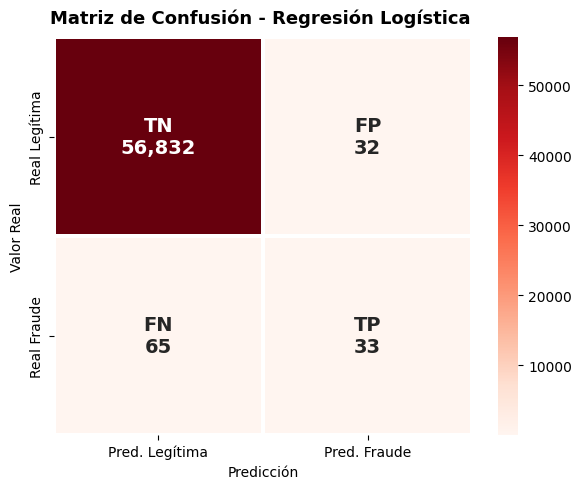

In [35]:
cm = confusion_matrix(y_test, y_pred_opt)
fig, ax = plt.subplots(figsize=(6,5))

plot_confusion(ax, cm, "Matriz de Confusión - Regresión Logística ","Reds")

plt.tight_layout()
plt.show()

*Naive Bayes*

In [36]:
scaler_nb = StandardScaler()
X_scaled = pd.DataFrame(scaler_nb.fit_transform(X), columns=X.columns)

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Fraudes en test: {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Train: 227,845  |  Test: 56,962
Fraudes en test: 98 (0.172%)


In [37]:
# SMOTE: balancear el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Distribución ANTES de SMOTE:", y_train.value_counts().to_dict())
print("Distribución DESPUÉS de SMOTE:", y_train_sm.value_counts().to_dict())

Distribución ANTES de SMOTE: {0: 227451, 1: 394}
Distribución DESPUÉS de SMOTE: {0: 227451, 1: 227451}


In [38]:
# Entrenamiento y predicción
nb = GaussianNB()
nb.fit(X_train_sm, y_train_sm)
y_pred_nb = nb.predict(X_test)

res_nb = calcular_metricas(y_test, y_pred_nb, "Naive Bayes")

  RESULTADOS: Naive Bayes
  TP (Fraude detectado)           :     75
  TN (Legítima correcta)          : 56,256
  FP (Falsa alarma)               :    608
  FN (Fraude no detectado)        :     23

  Accuracy            : 0.9889  (98.89%)
  Error Rate          : 0.0111  (1.11%)
  Precision           : 0.1098
  Recall (Sensibilidad): 0.7653
  Specificity         : 0.9893
  F1 Score            : 0.1921
  Balanced Accuracy   : 0.8773


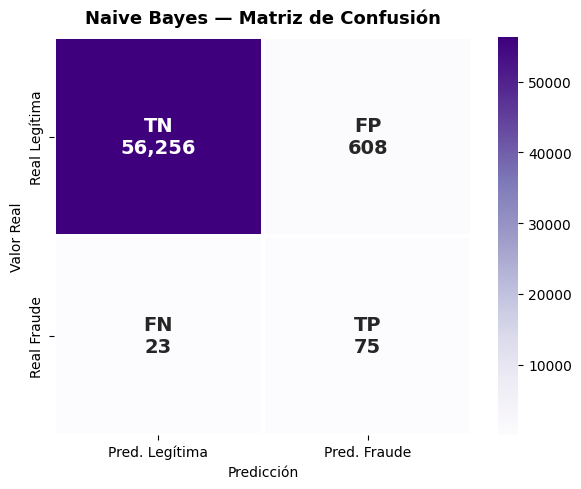

In [39]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion(ax, res_nb['cm'], "Naive Bayes — Matriz de Confusión", "Purples")
plt.tight_layout()
plt.show()

*Random Forest*

In [40]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
resultados_rf = calcular_metricas(y_test, y_pred_rf, "Random Forest")

  RESULTADOS: Random Forest
  TP (Fraude detectado)           :     59
  TN (Legítima correcta)          : 56,854
  FP (Falsa alarma)               :     10
  FN (Fraude no detectado)        :     39

  Accuracy            : 0.9991  (99.91%)
  Error Rate          : 0.0009  (0.09%)
  Precision           : 0.8551
  Recall (Sensibilidad): 0.6020
  Specificity         : 0.9998
  F1 Score            : 0.7066
  Balanced Accuracy   : 0.8009


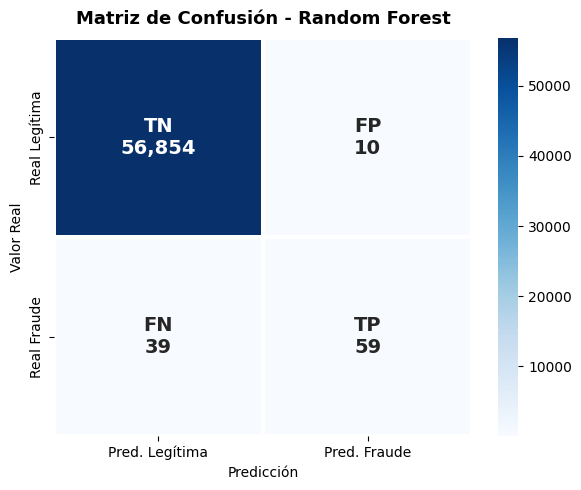

In [41]:
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6,5))

plot_confusion(ax, cm, "Matriz de Confusión - Random Forest", "Blues")

plt.tight_layout()
plt.show()

*Gradient Boosting*

  RESULTADOS: HistGradientBoosting
  TP (Fraude detectado)           :     71
  TN (Legítima correcta)          : 56,852
  FP (Falsa alarma)               :     12
  FN (Fraude no detectado)        :     27

  Accuracy            : 0.9993  (99.93%)
  Error Rate          : 0.0007  (0.07%)
  Precision           : 0.8554
  Recall (Sensibilidad): 0.7245
  Specificity         : 0.9998
  F1 Score            : 0.7845
  Balanced Accuracy   : 0.8621


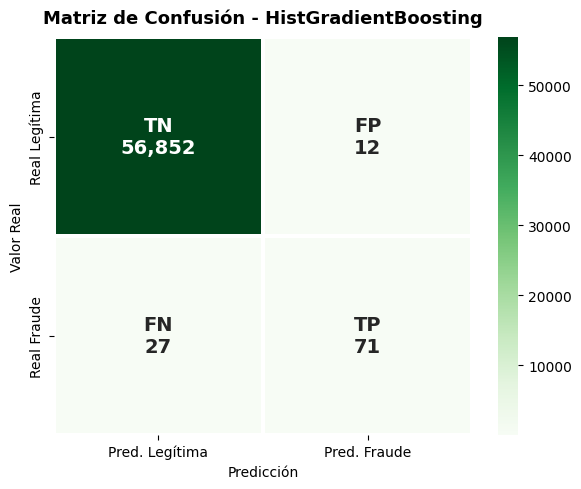

In [42]:
gb = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

resultados_gb = calcular_metricas(y_test, y_pred_gb, "HistGradientBoosting")

cm = confusion_matrix(y_test, y_pred_gb)
fig, ax = plt.subplots(figsize=(6,5))

plot_confusion(ax, cm, "Matriz de Confusión - HistGradientBoosting", "Greens")

plt.tight_layout()
plt.show()

*Isolation Forest*

In [43]:
N_LEGITIMAS = 10000  # puedes ajustar este número

fraudes   = df[df['Class'] == 1]
legitimas = df[df['Class'] == 0].sample(n=N_LEGITIMAS, random_state=42)

df_iso = pd.concat([fraudes, legitimas]).sample(frac=1, random_state=42).reset_index(drop=True)

X_iso = df_iso.drop(columns=['Class'])
y_iso = df_iso['Class']

scaler_iso = StandardScaler()
X_iso_scaled = scaler_iso.fit_transform(X_iso)

contaminacion = float(y_iso.sum()) / len(y_iso)
print(f"Dataset Isolation Forest: {len(df_iso):,} muestras")
print(f"  Fraudes   : {y_iso.sum():,}")
print(f"  Legítimas : {(y_iso==0).sum():,}")
print(f"  Contaminación: {contaminacion:.4f} ({contaminacion*100:.2f}%)")



Dataset Isolation Forest: 10,492 muestras
  Fraudes   : 492
  Legítimas : 10,000
  Contaminación: 0.0469 (4.69%)


In [44]:
iso = IsolationForest(
    n_estimators=300,
    contamination=contaminacion,
    max_samples='auto',
    bootstrap=True,
    random_state=42
)

iso.fit(X_iso_scaled)

scores = iso.decision_function(X_iso_scaled)

umbral = np.percentile(scores, contaminacion * 100)

y_pred_iso = (scores < umbral).astype(int)

In [45]:
res_iso = calcular_metricas(y_iso, y_pred_iso, "Isolation Forest Optimizado")

  RESULTADOS: Isolation Forest Optimizado
  TP (Fraude detectado)           :     13
  TN (Legítima correcta)          :  9,521
  FP (Falsa alarma)               :    479
  FN (Fraude no detectado)        :    479

  Accuracy            : 0.9087  (90.87%)
  Error Rate          : 0.0913  (9.13%)
  Precision           : 0.0264
  Recall (Sensibilidad): 0.0264
  Specificity         : 0.9521
  F1 Score            : 0.0264
  Balanced Accuracy   : 0.4893


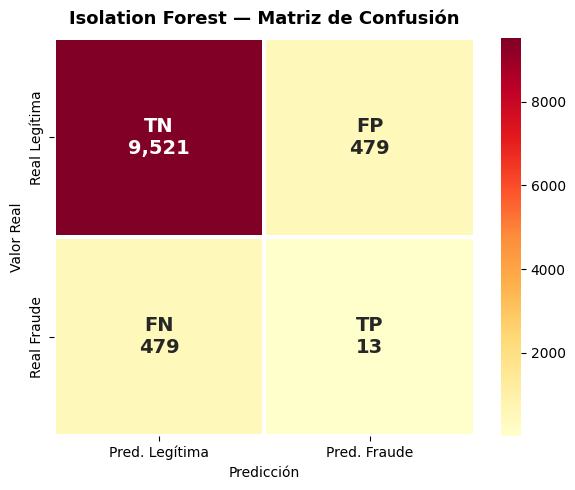

In [46]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion(ax, res_iso['cm'], "Isolation Forest — Matriz de Confusión", "YlOrRd")
plt.tight_layout()
plt.show()

*Local Outlier Factor (LOF)*

In [47]:
N_LEGITIMAS = 10000  # puedes ajustar este número

fraudes   = df[df['Class'] == 1]
legitimas = df[df['Class'] == 0].sample(n=N_LEGITIMAS, random_state=42)
df_lof    = pd.concat([fraudes, legitimas]).sample(frac=1, random_state=42).reset_index(drop=True)

X_lof = df_lof.drop(columns=['Class'])
y_lof = df_lof['Class']

scaler_lof = StandardScaler()
X_lof_scaled = scaler_lof.fit_transform(X_lof)

contaminacion = float(y_lof.sum()) / len(y_lof)
print(f"Dataset LOF: {len(df_lof):,} muestras")
print(f"  Fraudes   : {y_lof.sum():,}")
print(f"  Legítimas : {(y_lof==0).sum():,}")
print(f"  Contaminación: {contaminacion:.4f} ({contaminacion*100:.2f}%)")

Dataset LOF: 10,492 muestras
  Fraudes   : 492
  Legítimas : 10,000
  Contaminación: 0.0469 (4.69%)


In [48]:
# LOF en modo transductivo (fit_predict sobre el mismo conjunto)
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=contaminacion,
    n_jobs=-1
)

y_pred_lof_raw = lof.fit_predict(X_lof_scaled)

# LOF devuelve: -1 = outlier (fraude), +1 = inlier (legítimo)
y_pred_lof = np.where(y_pred_lof_raw == -1, 1, 0)

res_lof = calcular_metricas(y_lof, y_pred_lof, "Local Outlier Factor")


  RESULTADOS: Local Outlier Factor
  TP (Fraude detectado)           :     19
  TN (Legítima correcta)          :  9,527
  FP (Falsa alarma)               :    473
  FN (Fraude no detectado)        :    473

  Accuracy            : 0.9098  (90.98%)
  Error Rate          : 0.0902  (9.02%)
  Precision           : 0.0386
  Recall (Sensibilidad): 0.0386
  Specificity         : 0.9527
  F1 Score            : 0.0386
  Balanced Accuracy   : 0.4957


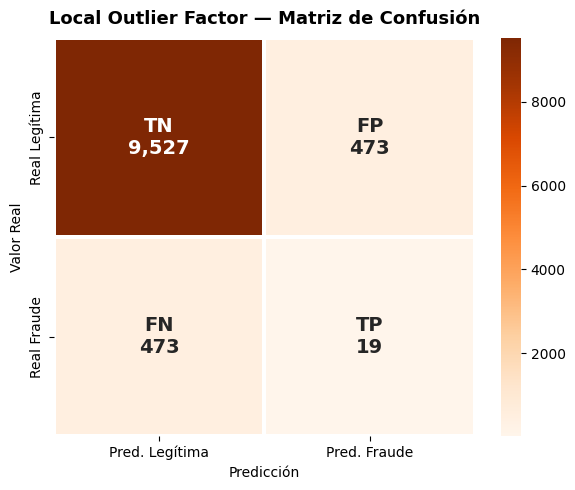

In [49]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion(ax, res_lof['cm'], "Local Outlier Factor — Matriz de Confusión", "Oranges")
plt.tight_layout()
plt.show()

*Comparación Conjunto de todos los modelos*

In [50]:
resultados_modelos = {
    "Regresión Logística": resultados_lr_opt,
    "Naive Bayes": res_nb,
    "Random Forest": resultados_rf,
    "XGBoost": resultados_gb,
    "Isolation Forest": res_iso,
    "LOF": res_lof
}

filas = []
for nombre, res in resultados_modelos.items():
    filas.append({
        "Modelo": nombre,
        "accuracy": res["accuracy"],
        "error": res["error"],
        "precision": res["precision"],
        "recall": res["recall"],
        "specificity": res["specificity"],
        "f1": res["f1"],
        "balanced_accuracy": res["balanced_accuracy"],
        "TP": res["TP"],
        "TN": res["TN"],
        "FP": res["FP"],
        "FN": res["FN"]
    })

df_resumen = pd.DataFrame(filas)
df_resumen = df_resumen.sort_values(by=["recall", "f1", "precision"], ascending=False)
display(df_resumen)

,Modelo,accuracy,error,precision,recall,specificity,f1,balanced_accuracy,TP,TN,FP,FN
1,Naive Bayes,0.988922,0.011078,0.109810,0.765306,0.989308,0.192061,0.877307,75,56256,608,23
3,XGBoost,0.999315,0.000685,0.855422,0.724490,0.999789,0.784530,0.862139,71,56852,12,27
2,Random Forest,0.999140,0.000860,0.855072,0.602041,0.999824,0.706587,0.800932,59,56854,10,39
0,Regresión Logística,0.998297,0.001703,0.507692,0.336735,0.999437,0.404908,0.668086,33,56832,32,65
5,LOF,0.909836,0.090164,0.038618,0.038618,0.952700,0.038618,0.495659,19,9527,473,473
4,Isolation Forest,0.908692,0.091308,0.026423,0.026423,0.952100,0.026423,0.489261,13,9521,479,479


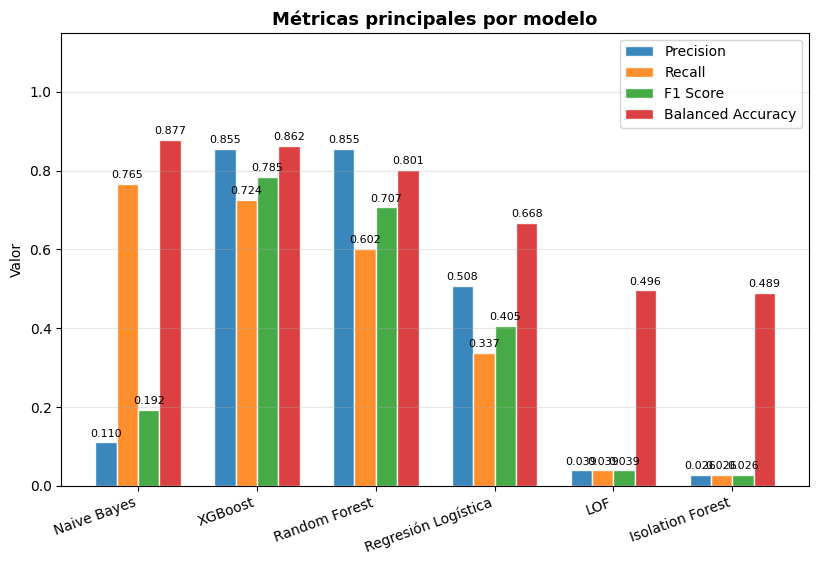

In [51]:
fig = plt.figure(figsize=(22, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])

metricas_principales = ["precision", "recall", "f1", "balanced_accuracy"]
nombres_metricas = ["Precision", "Recall", "F1 Score", "Balanced Accuracy"]

df_plot = df_resumen.set_index("Modelo")[metricas_principales]

x = np.arange(len(df_plot.index))
width = 0.18

for i, metrica in enumerate(metricas_principales):
    bars = ax1.bar(
        x + (i - 1.5) * width,
        df_plot[metrica],
        width=width,
        label=nombres_metricas[i],
        alpha=0.88,
        edgecolor="white"
    )

    for bar in bars:
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax1.set_xticks(x)
ax1.set_xticklabels(df_plot.index, rotation=20, ha="right")
ax1.set_ylim(0, 1.15)
ax1.set_ylabel("Valor")
ax1.set_title("Métricas principales por modelo", fontsize=13, fontweight="bold")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()